# Craig Transform

Transforming $G_{UV},\,G_{NE}$ to $g_{D}$

The Craig transform provides functionality to generate gravity from differential curvatures.

Here we demonstrate its use on publicly available data from the Fosterville Falcon airborne gravity gradiometer survey.

This a first draft of the Craig Transform tutorial.

## Fosterville Example

...

___
Import the required modules, and set the path to the geowhizz files.

In [1]:
from pathlib import Path
import pegasusQC as qc

data_root = r'/Volumes/MHD Data2024/TestData/2019_Falcon_Fosterville/'
FostervilleHDF_file = Path(data_root + r'803064_AGG_Located_20191108_EL3539.hdf5')

reg_root = r'/Volumes/MHD Data2024/TestData/2019_Falcon_Fosterville/regional/'
regional_fa_ers = Path(reg_root + r'Gravmap2019-grid-grv_fa.ers')

In [5]:
if not FostervilleHDF_file.exists():
    print("Ask Mark for help!!!")
    # %run ./Prepare_EastVicData.ipynb

In [6]:
# Find the channel names for the free-air Gne and Guv data
qc.reportChannels(FostervilleHDF_file)

Whizz Version 1.0

50 channels:


50 channels:
 ['Date_Local', 'Diff_AmB_NE_2p67_0p18HzLP', 'Diff_AmB_UV_2p67_0p18HzLP', 'Elevation_GNSS_EGM96', 'Elevation_GNSS_GRS80', 'Falc_A_NE_0p00_0p18Hz_MeanLev', 'Falc_A_NE_2p67_0p18Hz_MeanLev', 'Falc_A_UV_0p00_0p18Hz_MeanLev', 'Falc_A_UV_2p67_0p18Hz_MeanLev', 'Falc_B_NE_0p00_0p18Hz_MeanLev', 'Falc_B_NE_2p67_0p18Hz_MeanLev', 'Falc_B_UV_0p00_0p18Hz_MeanLev', 'Falc_B_UV_2p67_0p18Hz_MeanLev', 'Falc_Corr_TC_DD_1p00_0p18HzLP_TCGrid_DSM_EGM96', 'Falc_Corr_TC_NE_1p00_0p18HzLP_TCGrid_DSM_EGM96', 'Falc_Corr_TC_UV_1p00_0p18HzLP_TCGrid_DSM_EGM96', 'Falc_GDD_0p00_0p18HzLP_ESD300m_SDS', 'Falc_GDD_2p67_0p18HzLP_ESD300m_SDS', 'Falc_GED_0p00_0p18HzLP_ESD300m_SDS', 'Falc_GED_2p67_0p18HzLP_ESD300m_SDS', 'Falc_GEE_0p00_0p18HzLP_ESD300m_SDS', 'Falc_GEE_2p67_0p18HzLP_ESD300m_SDS', 'Falc_GND_0p00_0p18HzLP_ESD300m_SDS', 'Falc_GND_2p67_0p18HzLP_ESD300m_SDS', 'Falc_GNE_0p00_0p18HzLP_ESD300m_SDS', 'Falc_GNE_2p67_0p18HzLP_ESD300m_SDS', 'Falc_GNN_0p00_0p18HzLP_ESD300m_SDS',

Perhaps that does not help everyone. I need to remove un-needed channels for this tutorial!! Anyway, I can see the names I want, and put them in the call below.

206 lines; total number of fids in whizz file = 366670.
    Falc_A_NE_0p00_0p18Hz_MeanLev: min = -51.8, max = 39.8, mean = 0.0262.

206 lines; total number of fids in whizz file = 366670.
    Falc_A_UV_0p00_0p18Hz_MeanLev: min = -41.5, max = 67.7, mean = -0.312.

Processing (x, y, z) = (GNSS_Easting_WGS84UTM55, GNSS_Northing_WGS84UTM55, Falc_A_NE_0p00_0p18Hz_MeanLev). Falc_A_NE_0p00_0p18Hz_MeanLev in unknown units.
Setting up grid...
Creating nearest neighbour starting value...
Organizing input data...
1 point(s) excluded.
Creating minimum curvature grid...
Finished!
Processing (x, y, z) = (GNSS_Easting_WGS84UTM55, GNSS_Northing_WGS84UTM55, Falc_A_UV_0p00_0p18Hz_MeanLev). Falc_A_UV_0p00_0p18Hz_MeanLev in unknown units.
Setting up grid...
Creating nearest neighbour starting value...
Organizing input data...
1 point(s) excluded.
Creating minimum curvature grid...
Finished!
Wavenumber resolution = 8.88e-06
Equivalent wavelength = 1.13e+05 m.
RMS of result = 1.83
min of result = -23.12
max

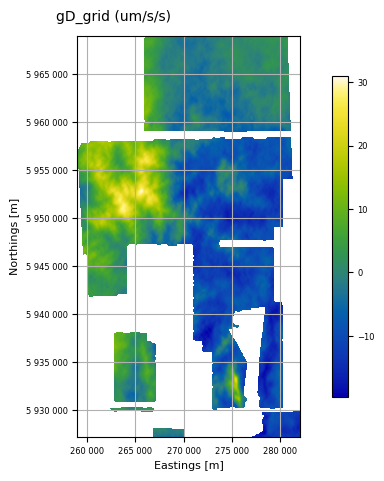

RMS of result = 7.35
min of result = -16.16
max of result = 20.71
Array shape = (418, 233)


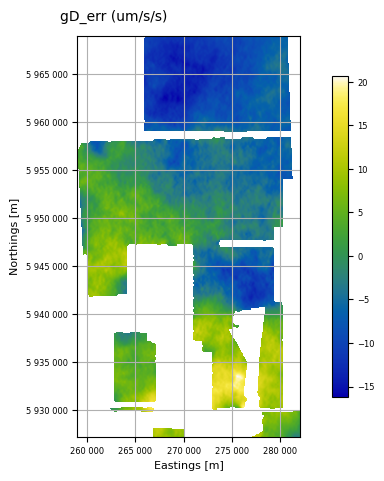

In [2]:
gD_grid, Ane_grid = qc.craig_transform(
    whizzFile=FostervilleHDF_file, gne_chan='Falc_A_NE_0p00_0p18Hz_MeanLev', guv_chan='Falc_A_UV_0p00_0p18Hz_MeanLev',
    cell_size=100.0, unit_scale=1000.0, mask_polygon=None,
    pad_cells=256, padding_mode="regional", regional_grid_file=regional_fa_ers
)

206 lines; total number of fids in whizz file = 366670.
    Falc_A_NE_0p00_0p18Hz_MeanLev: min = -51.8, max = 39.8, mean = 0.0262.

206 lines; total number of fids in whizz file = 366670.
    Falc_A_UV_0p00_0p18Hz_MeanLev: min = -41.5, max = 67.7, mean = -0.312.

Processing (x, y, z) = (GNSS_Easting_WGS84UTM55, GNSS_Northing_WGS84UTM55, Falc_A_NE_0p00_0p18Hz_MeanLev). Falc_A_NE_0p00_0p18Hz_MeanLev in unknown units.
Setting up grid...
Creating nearest neighbour starting value...
Organizing input data...
1 point(s) excluded.
Creating minimum curvature grid...
Finished!
Processing (x, y, z) = (GNSS_Easting_WGS84UTM55, GNSS_Northing_WGS84UTM55, Falc_A_UV_0p00_0p18Hz_MeanLev). Falc_A_UV_0p00_0p18Hz_MeanLev in unknown units.
Setting up grid...
Creating nearest neighbour starting value...
Organizing input data...
1 point(s) excluded.
Creating minimum curvature grid...
Finished!
Wavenumber resolution = 8.88e-06
Equivalent wavelength = 1.13e+05 m.
Making first order tilt correction to transform

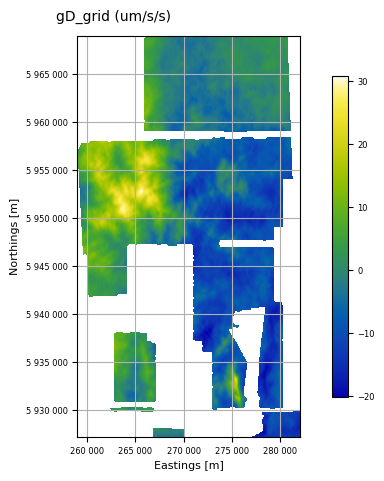

RMS of result = 7.41
min of result = -16.15
max of result = 21.60
Array shape = (418, 233)


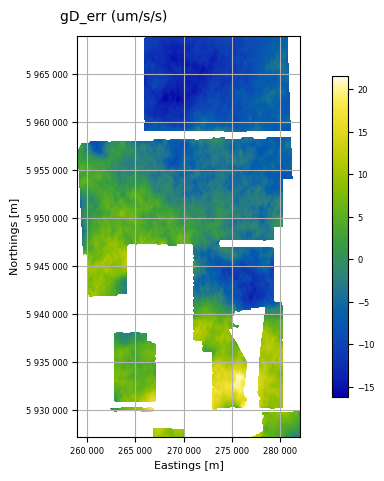

In [3]:
gD_grid, Ane_grid = qc.craig_transform(
    whizzFile=FostervilleHDF_file, gne_chan='Falc_A_NE_0p00_0p18Hz_MeanLev', guv_chan='Falc_A_UV_0p00_0p18Hz_MeanLev',
    cell_size=100.0, unit_scale=1000.0, mask_polygon=None,
    pad_cells=256, padding_mode="regional", regional_grid_file=regional_fa_ers,
    firstorder=True
)

## Telfer Example

In [35]:
from pathlib import Path
import pegasusQC as qc

data_root = r'/Volumes/MHD Data2024/TestData/2010_Falcon_Telfer/'
TelferHDF_file = Path(data_root + r'2131_1_aggFin.hdf5')

reg_root = r'/Volumes/MHD Data2024/TestData/2010_Falcon_Telfer/regional/'
regional_fa_ers = Path(reg_root + r'Gravmap2019-grid-grv_dtgir.ers')

true_gd_ers = Path(data_root + r'2131_1_Fourier_gD_2p2_conformed_final.ers')

In [5]:
if not TelferHDF_file.exists():
    print("Ask Mark for help!!!")
    # %run ./Prepare_EastVicData.ipynb

In [10]:
# Find the channel names for the free-air Gne and Guv data
qc.reportChannels(TelferHDF_file)

Whizz Version 1.0

56 channels:


56 channels:
 ['ALTITUDE_Ellipsoid', 'A_NE_0', 'A_NE_2p2', 'A_NE_2p67', 'A_UV_0', 'A_UV_2p2', 'A_UV_2p67', 'B_NE_0', 'B_NE_2p2', 'B_NE_2p67', 'B_UV_0', 'B_UV_2p2', 'B_UV_2p67', 'DRAPESURFACE_FOURIER', 'DTM', 'Date', 'EASTING', 'Err_NE', 'Err_UV', 'FIDUCIAL', 'Flight', 'GDD_FOURIER_0', 'GDD_FOURIER_2p2', 'GDD_FOURIER_2p67', 'GED_FOURIER_0', 'GED_FOURIER_2p2', 'GED_FOURIER_2p67', 'GEE_FOURIER_0', 'GEE_FOURIER_2p2', 'GEE_FOURIER_2p67', 'GND_FOURIER_0', 'GND_FOURIER_2p2', 'GND_FOURIER_2p67', 'GNE_FOURIER_0', 'GNE_FOURIER_2p2', 'GNE_FOURIER_2p67', 'GNN_FOURIER_0', 'GNN_FOURIER_2p2', 'GNN_FOURIER_2p67', 'GUV_FOURIER_0', 'GUV_FOURIER_2p2', 'GUV_FOURIER_2p67', 'LATITUDE', 'LEVMAG', 'LONGITUDE', 'Line', 'NORTHING', 'RADAR', 'TURBULENCE', 'T_DD', 'T_NE', 'T_UV', 'fHEIGHT', 'gD_FOURIER_0', 'gD_FOURIER_2p2', 'gD_FOURIER_2p67']


269 lines; total number of fids in whizz file = 1122946.
    A_NE_2p67: min = -161, max = 40.1, mean = -22.3.

269 lines; total number of fids in whizz file = 1122946.
    A_UV_2p67: min = -96.2, max = 52.7, mean = -28.9.

Processing (x, y, z) = (EASTING, NORTHING, A_NE_2p67). A_NE_2p67 in eotvos.
Setting up grid...
Creating nearest neighbour starting value...
Organizing input data...
11 point(s) excluded.
Creating minimum curvature grid...
Finished!
Processing (x, y, z) = (EASTING, NORTHING, A_UV_2p67). A_UV_2p67 in eotvos.
Setting up grid...
Creating nearest neighbour starting value...
Organizing input data...
11 point(s) excluded.
Creating minimum curvature grid...
Finished!
Wavenumber resolution = 3.36e-06
Equivalent wavelength = 2.98e+05 m.
Making first order tilt correction to transform FROM gravity.
RMS of result = 1.93
min of result = -15.83
max of result = 17.68
Array shape = (777, 677)
RMS of result = 9.75 eotvos
min of result = -132.97 eotvos
max of result = 38.91 eotvos
Arr

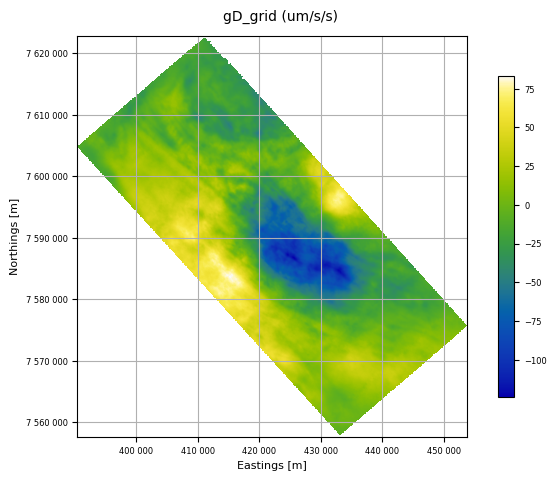

RMS of result = 20.73
min of result = -32.84
max of result = 73.26
Array shape = (653, 635)


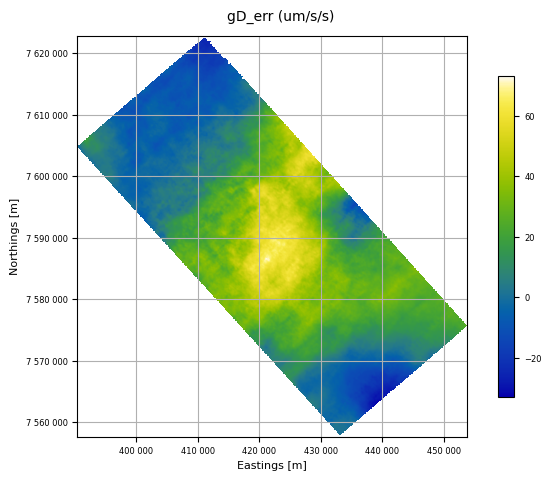

In [11]:
gD_grid, Ane_grid = qc.craig_transform(
    whizzFile=TelferHDF_file, gne_chan='A_NE_2p67', guv_chan='A_UV_2p67',
    cell_size=100.0, unit_scale=1000.0, mask_polygon=None,
    pad_cells=256, padding_mode="regional", regional_grid_file=regional_fa_ers,
    firstorder=True
)

269 lines; total number of fids in whizz file = 1122946.
    A_NE_2p67: min = -161, max = 40.1, mean = -22.3.

269 lines; total number of fids in whizz file = 1122946.
    A_UV_2p67: min = -96.2, max = 52.7, mean = -28.9.

Processing (x, y, z) = (EASTING, NORTHING, A_NE_2p67). A_NE_2p67 in eotvos.
Setting up grid...
Creating nearest neighbour starting value...
Organizing input data...
11 point(s) excluded.
Creating minimum curvature grid...
Finished!
Processing (x, y, z) = (EASTING, NORTHING, A_UV_2p67). A_UV_2p67 in eotvos.
Setting up grid...
Creating nearest neighbour starting value...
Organizing input data...
11 point(s) excluded.
Creating minimum curvature grid...
Finished!
Wavenumber resolution = 3.36e-06
Equivalent wavelength = 2.98e+05 m.
RMS of result = 1.93
min of result = -15.83
max of result = 17.68
Array shape = (777, 677)
RMS of result = 9.75 eotvos
min of result = -132.97 eotvos
max of result = 38.91 eotvos
Array shape = (653, 637)
RMS of result = 1.91
min of result = -20

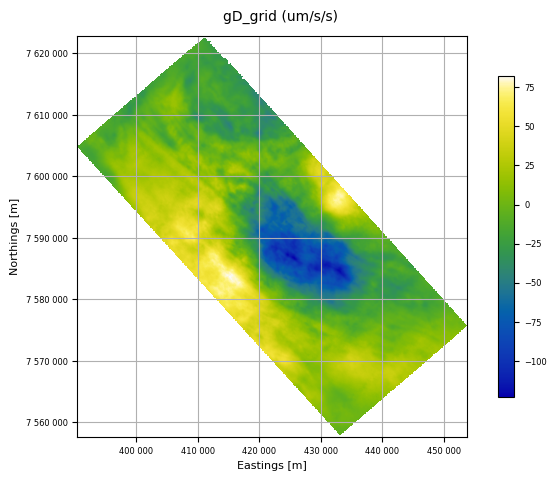

RMS of result = 20.00
min of result = -31.00
max of result = 69.86
Array shape = (653, 635)


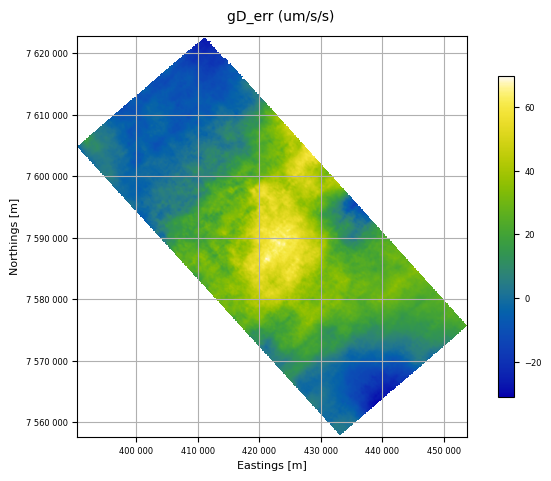

In [12]:
gD_grid, Ane_grid = qc.craig_transform(
    whizzFile=TelferHDF_file, gne_chan='A_NE_2p67', guv_chan='A_UV_2p67',
    cell_size=100.0, unit_scale=1000.0, mask_polygon=None,
    pad_cells=256, padding_mode="regional", regional_grid_file=regional_fa_ers,
    firstorder=False
)

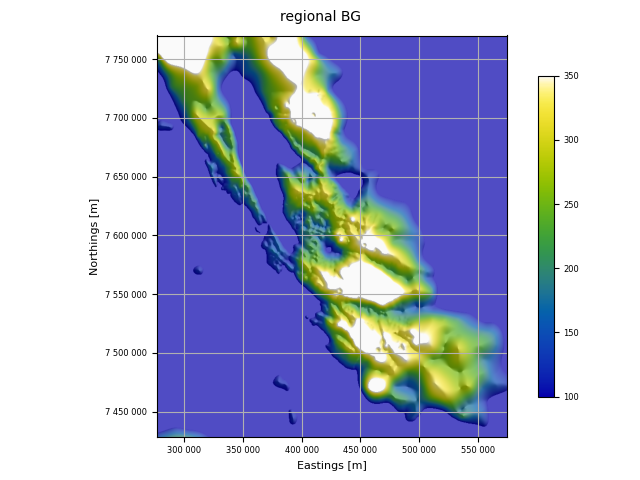

In [32]:
%matplotlib widget
reg_bg, _ = qc.gridfile_to_xa(regional_fa_ers)
qc.xdImage(reg_bg, 'regional BG', minClip=100, maxClip=350)

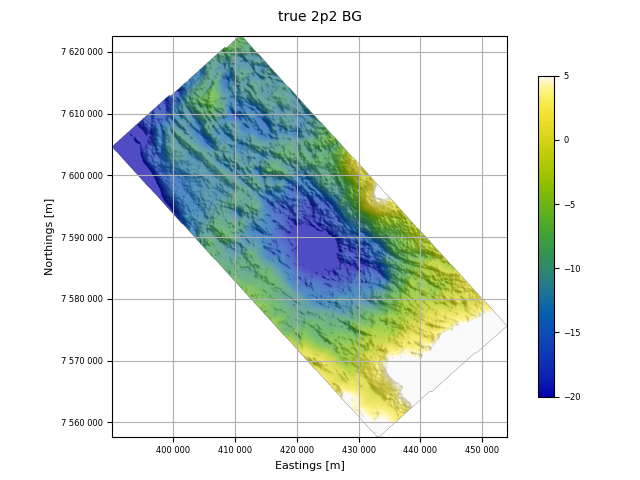

In [39]:
%matplotlib widget
true_bg, _ = qc.gridfile_to_xa(true_gd_ers)
qc.xdImage(true_bg, 'true 2p2 BG', minClip=-20, maxClip=5)

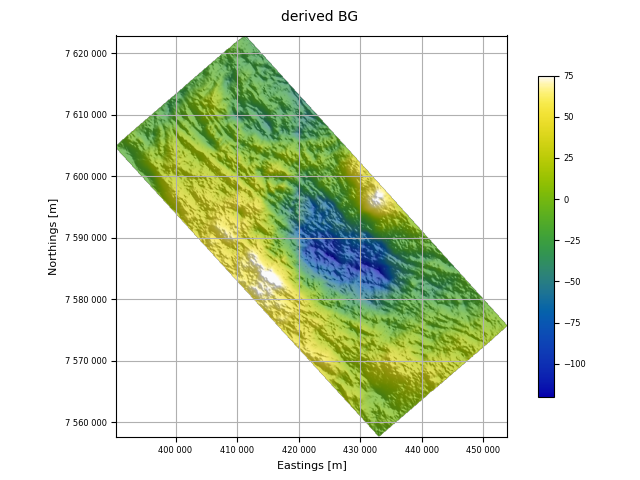

In [26]:
qc.xdImage(gD_grid, 'derived BG', hs=True, minClip=-120, maxClip=75)